# `capillary_transform`
Converts a distance-transform map into a capillary-pressure map using the Washburn equation, optionally including a hydrostatic gravity term.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.capillary_transform)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], dt: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]] = None, sigma: float = 1.0, theta: float = 180, g: float = 0.0, rho_wp: float = 0.0, rho_nwp: float = 0.0, voxel_size: float = 1.0, spacing: float = None)>

## `im`
A boolean image with `True` indicating the void phase. The capillary pressure is computed for every void voxel from its distance to the nearest solid (via the distance transform).

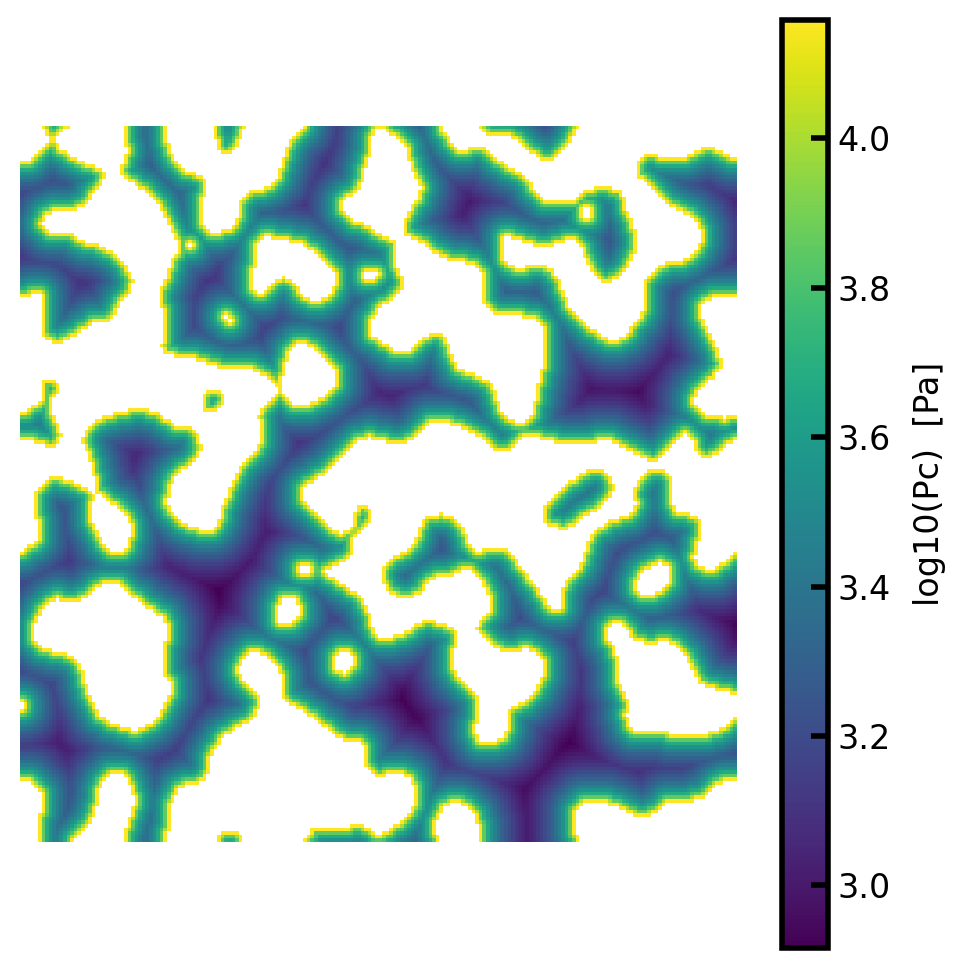

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
pc = ps.filters.capillary_transform(im=im, sigma=0.072, theta=180, voxel_size=1e-5)

fig, ax = plt.subplots(figsize=[5, 5])
h = ax.imshow(np.log10(pc) / im, origin='lower', interpolation='none')
fig.colorbar(h, ax=ax, label='log10(Pc)  [Pa]')
ax.axis(False);

## `sigma` and `theta`
`sigma` is the fluid-fluid surface tension (e.g. 0.072 N/m for water-air) and `theta` is the contact angle measured through the non-wetting phase, in degrees. `theta` must be between 90 and 180.

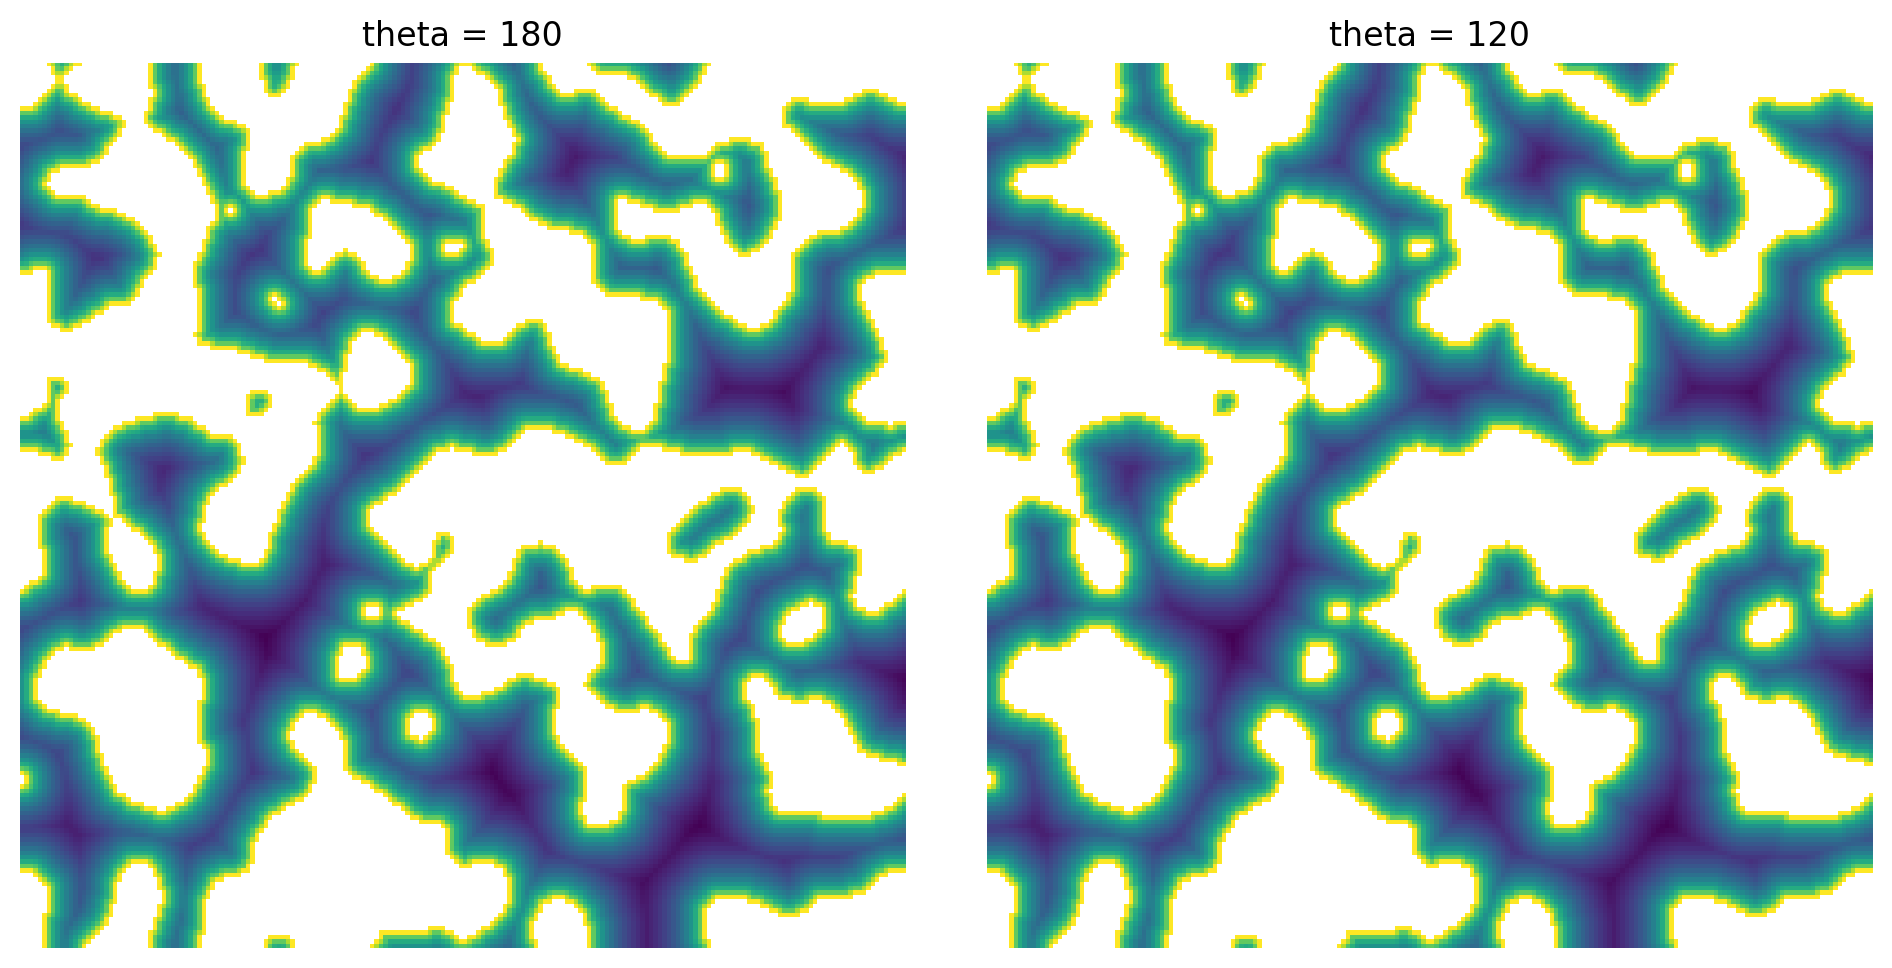

In [4]:
pc1 = ps.filters.capillary_transform(im=im, sigma=0.072, theta=180, voxel_size=1e-5)
pc2 = ps.filters.capillary_transform(im=im, sigma=0.072, theta=120, voxel_size=1e-5)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(np.log10(pc1) / im, origin='lower', interpolation='none')
ax[0].set_title('theta = 180')
ax[0].axis(False)
ax[1].imshow(np.log10(pc2) / im, origin='lower', interpolation='none')
ax[1].set_title('theta = 120')
ax[1].axis(False);

## `voxel_size`
Physical resolution of the image, in metres per voxel side. The distance transform is multiplied by `voxel_size` before being fed to the Washburn equation, so this directly sets the absolute scale of `pc`.

In [5]:
for vs in [1e-6, 1e-5, 1e-4]:
    pc = ps.filters.capillary_transform(
        im=im, sigma=0.072, theta=180, voxel_size=vs)
    print(f'voxel_size = {vs:.0e}  ->  median Pc = {np.median(pc[im]):.3e} Pa')

voxel_size = 1e-06  ->  median Pc = 2.880e+04 Pa
voxel_size = 1e-05  ->  median Pc = 2.880e+03 Pa
voxel_size = 1e-04  ->  median Pc = 2.880e+02 Pa


## `g`, `rho_nwp`, `rho_wp`
Including gravity adds a hydrostatic term `(rho_nwp - rho_wp) * g * h`, where `h` is the distance along axis 0 in physical units. The result is a Pc that is no longer purely a function of pore size, so the same pore can have different entry pressures at different heights.

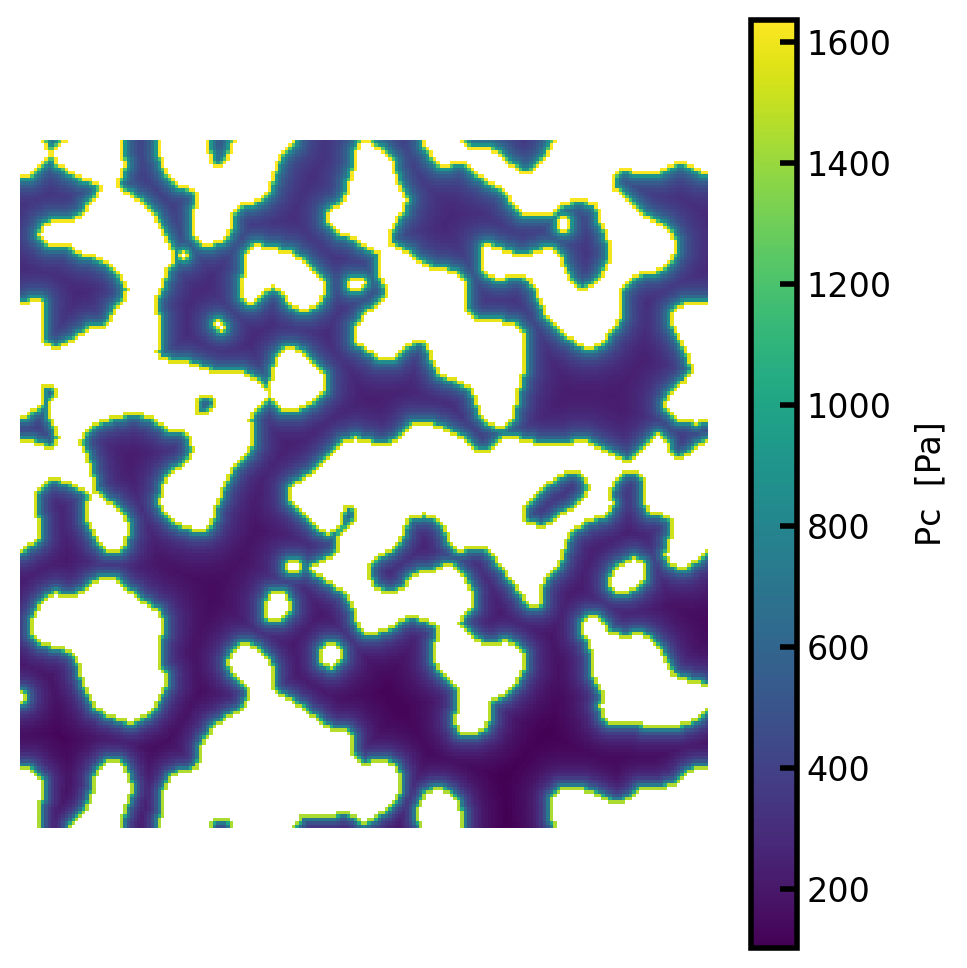

In [6]:
pc = ps.filters.capillary_transform(
    im=im,
    sigma=0.072,
    theta=180,
    g=9.81,
    rho_nwp=1000.0,
    rho_wp=0.0,
    voxel_size=1e-4,
)

fig, ax = plt.subplots(figsize=[5, 5])
h = ax.imshow(pc / im, origin='lower', interpolation='none')
fig.colorbar(h, ax=ax, label='Pc  [Pa]')
ax.axis(False);

## `dt`
If a distance transform of the void phase is already on hand, passing it via `dt` skips the recomputation. The result is identical.

In [7]:
from porespy.tools import get_edt

dt = get_edt()(im)
pc = ps.filters.capillary_transform(
    im=im, dt=dt, sigma=0.072, theta=180, voxel_size=1e-5)

## `spacing`
Only relevant for 2D images. By default a 2D image is treated as a slice of a 3D system, so the second radius of curvature is taken as the in-plane distance transform itself. Setting `spacing` to a physical out-of-plane distance adds a second curvature term `2/spacing`. Setting `spacing=np.inf` drops the second curvature entirely, giving a true-2D Washburn equation.

In [8]:
pc_3d_like = ps.filters.capillary_transform(
    im=im, sigma=0.072, theta=180, voxel_size=1e-5)
pc_2d = ps.filters.capillary_transform(
    im=im, sigma=0.072, theta=180, voxel_size=1e-5, spacing=np.inf)

print(f'3D-like median Pc: {np.median(pc_3d_like[im]):.3e} Pa')
print(f'true-2D median Pc: {np.median(pc_2d[im]):.3e} Pa')

3D-like median Pc: 2.880e+03 Pa
true-2D median Pc: 1.440e+03 Pa
